# 03c — Fine-tuning Eficiente: LoRA, QLoRA y Cuándo Adaptar Modelos

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque3/03c-fine-tuning.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 3 — Aplicaciones**. Se recomienda
> haber completado los [Bloques 1](../bloque1/01-fundamentos.qmd) y
> [2](../bloque2/02-orquestacion.qmd) primero.

In [1]:
!pip install -q transformers peft bitsandbytes trl datasets torch accelerate python-dotenv

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

## Fine-tuning Eficiente

### ¿Qué es fine-tuning y por qué es difícil?

Un LLM preentrenado es como un **médico generalista**: sabe de todo un
poco. Hacer fine-tuning es como enviarlo a una **especialización de 6
meses**: sale sabiendo mucho de un tema concreto sin olvidar lo general.

El fine-tuning consiste en tomar un modelo base preentrenado y
**entrenarlo adicionalmente** con datos de tu dominio para que adapte su
comportamiento: nuevo tono, nuevo formato de salida, nuevo vocabulario
técnico, o nuevo conocimiento específico.

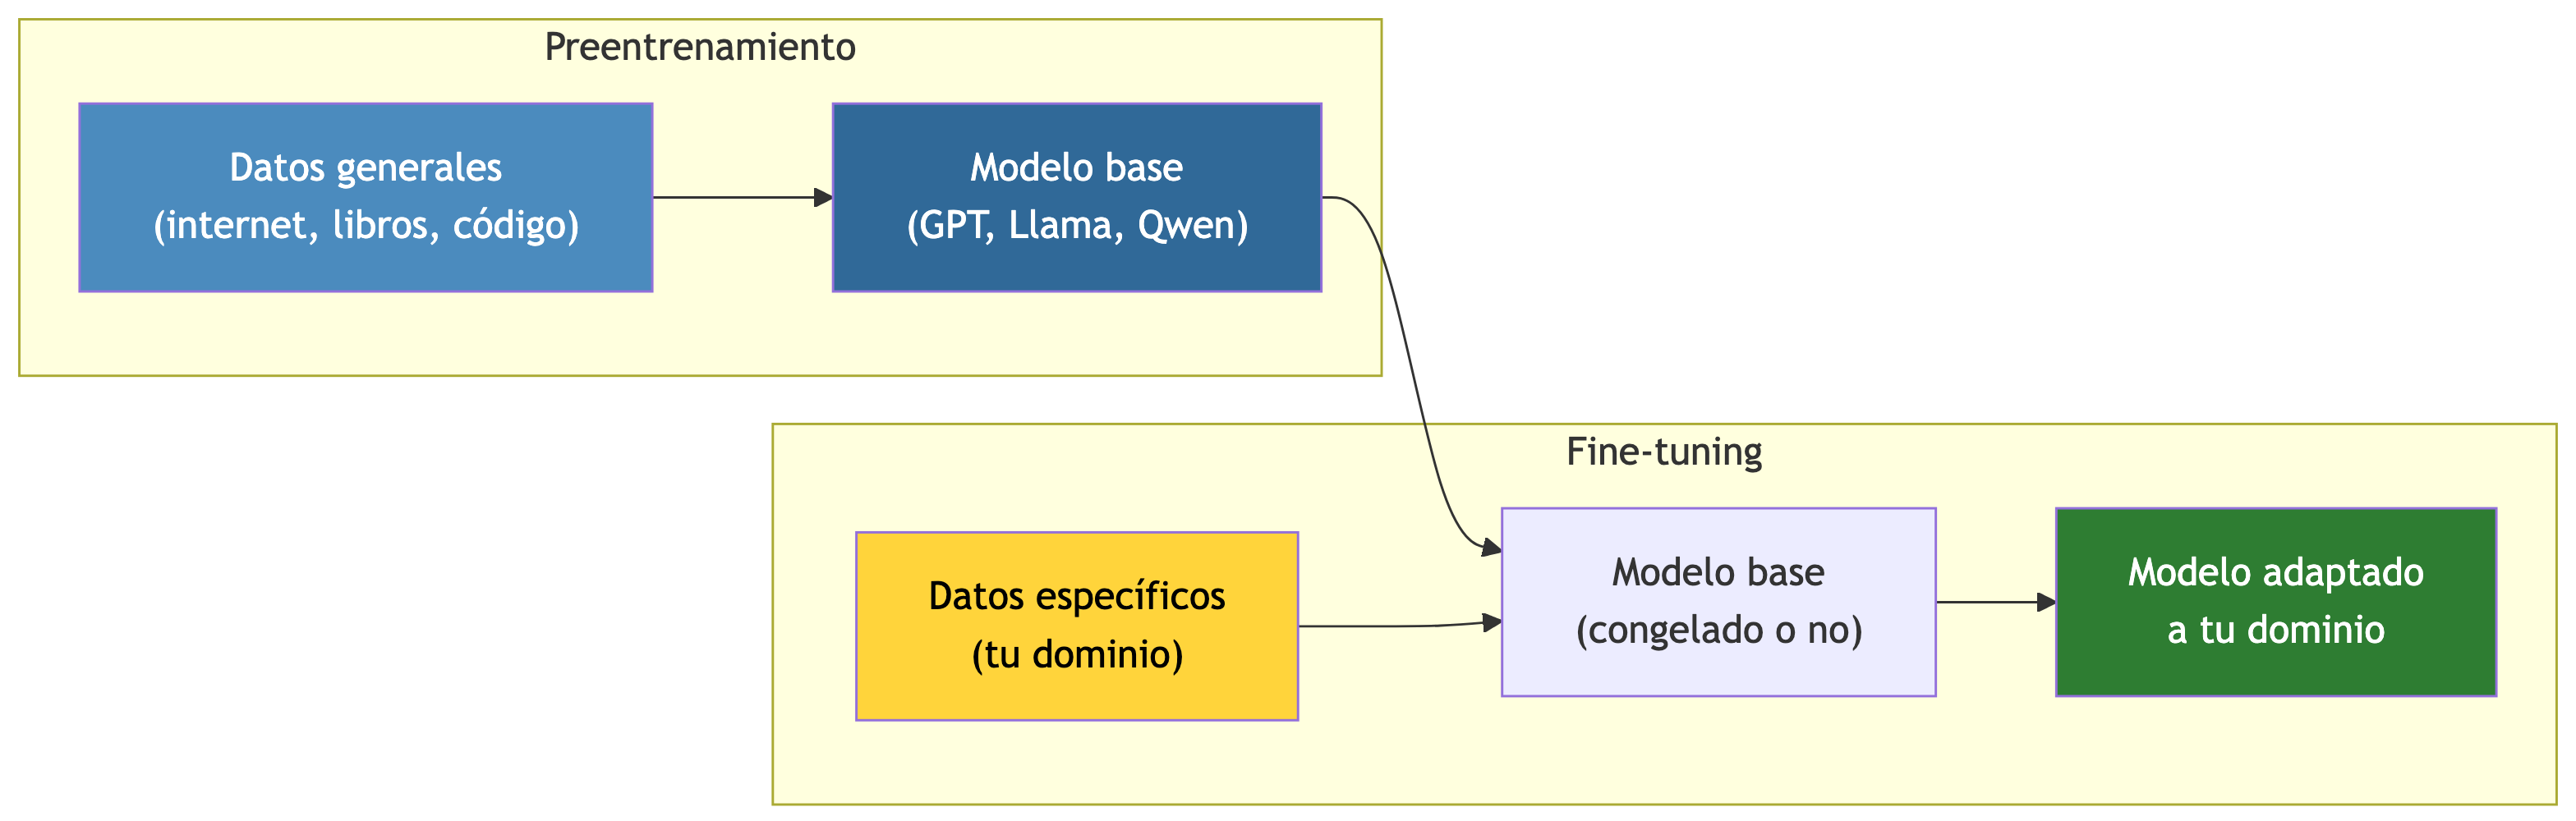

El problema es la **escala**. Los modelos modernos tienen miles de
millones de parámetros, y entrenarlos completamente requiere una
cantidad de memoria GPU prohibitiva:

| Modelo | Parámetros | RAM para fine-tuning completo | Coste GPU/hora |
|----|----|----|----|
| Llama 3.3 70B | 70 mil millones | ~560 GB | ~\$50/h (A100 80GB) |
| Qwen 3 7B | 7 mil millones | ~56 GB | ~\$5/h (A100 80GB) |
| Gemma 2B | 2 mil millones | ~16 GB | ~\$1/h (T4 16GB) |

> **El problema de memoria**
>
> Fine-tuning completo de un modelo 7B requiere ~56 GB de RAM: 14 GB
> para los pesos + 28 GB para los gradientes + 14 GB para los estados
> del optimizador Adam. Una GPU de consumidor (RTX 4090: 24 GB) no
> basta. Aquí entran las técnicas **PEFT** (Parameter-Efficient
> Fine-Tuning).

------------------------------------------------------------------------

### La decisión clave: ¿Fine-tuning, RAG o Prompting?

Antes de hacer fine-tuning, pregúntate si realmente lo necesitas. La
mayoría de las veces, **RAG o prompting son suficientes**.

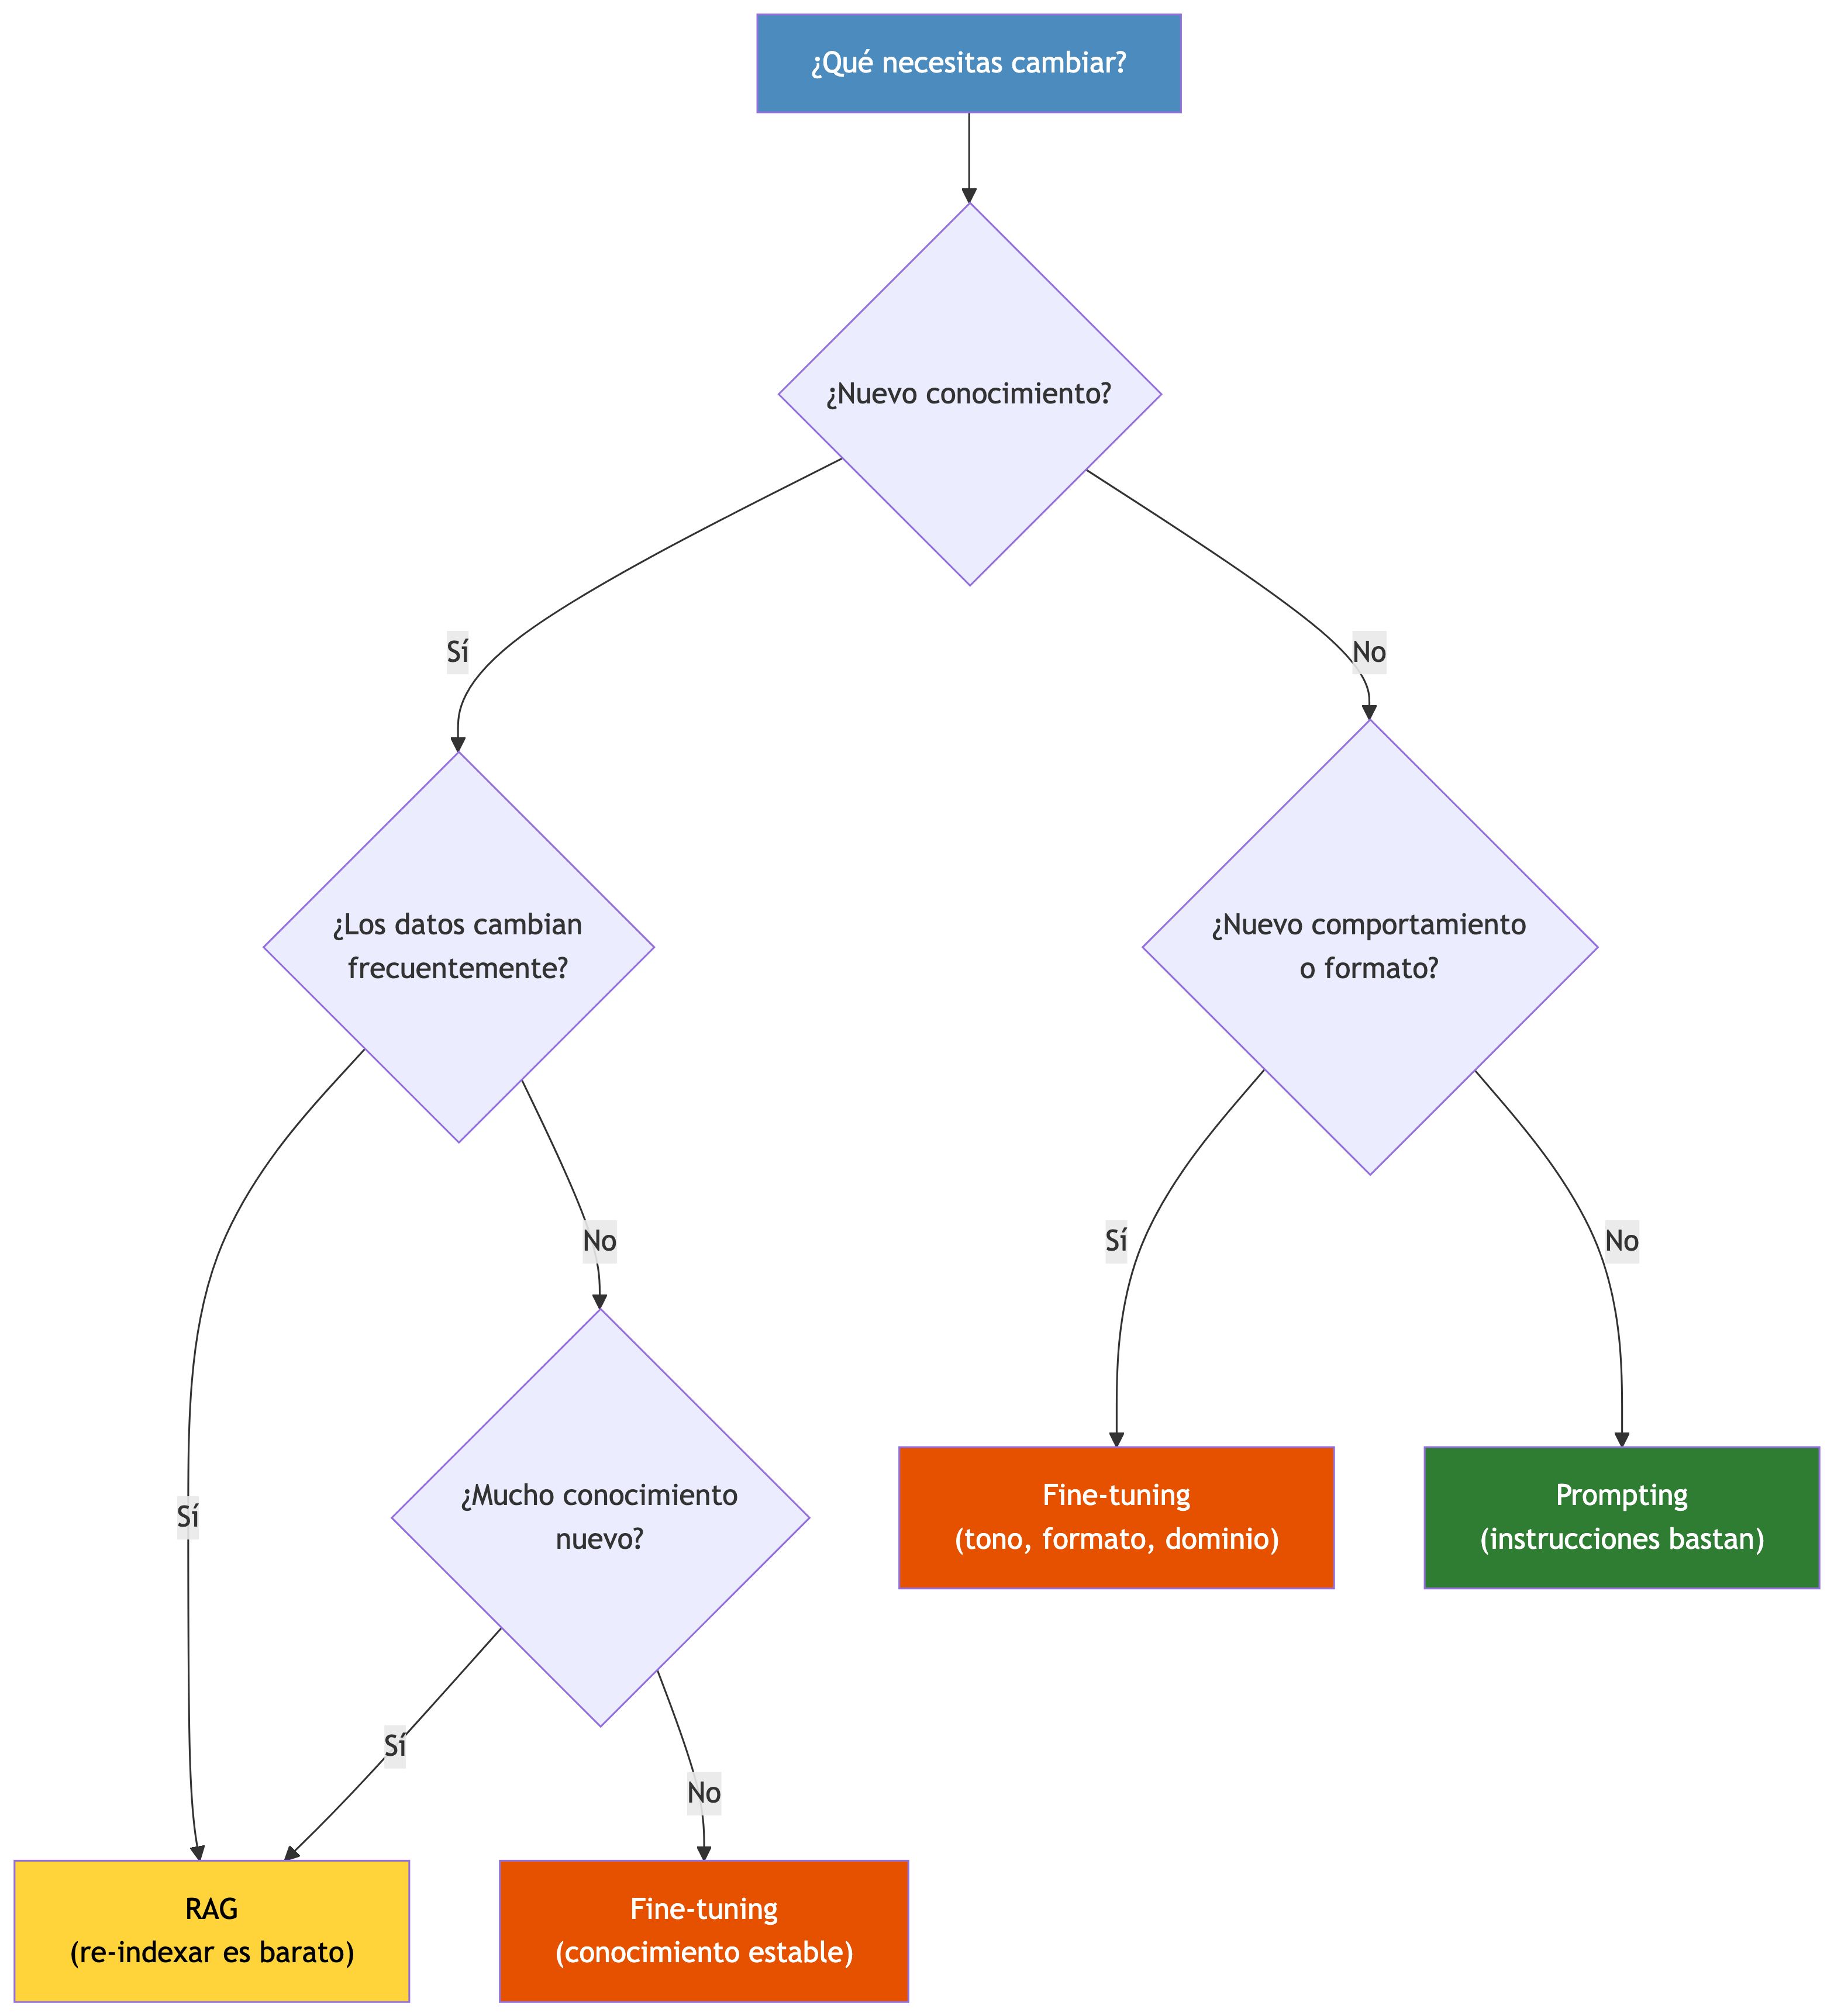

| Criterio | Prompting | RAG | Fine-tuning |
|------------------|------------------|------------------|------------------|
| **Nuevo conocimiento** | No | Sí | Sí (limitado) |
| **Nuevo formato/comportamiento** | Limitado | No | Sí |
| **Latencia añadida** | Ninguna | Retrieval (ms) | Ninguna |
| **Coste de setup** | Minutos | Horas | Horas + GPU |
| **Mantenimiento** | Editar prompt | Pipeline + Vector DB | Re-entrenar |
| **Actualización de datos** | Editar prompt | Re-indexar | Re-entrenar |
| **Ejemplo de uso** | Extraer JSON | Buscar en documentos corporativos | Adaptar tono médico/legal |

> **Regla práctica**
>
> 1.  **Empieza con prompting.** Si no basta, añade RAG.
> 2.  **Si necesitas un comportamiento muy específico** (tono, formato,
>     vocabulario de dominio), considera fine-tuning.
> 3.  **Si necesitas conocimiento actualizable**, usa RAG. El
>     fine-tuning no se actualiza sin re-entrenar.
> 4.  **Si necesitas ambos** (conocimiento + comportamiento), combina
>     RAG + fine-tuning.

------------------------------------------------------------------------

### LoRA: Low-Rank Adaptation

**LoRA** es la técnica PEFT más popular. En vez de reescribir todos los
pesos del modelo, añade pequeñas “notas adhesivas” (matrices de bajo
rango) que modifican el comportamiento sin tocar el modelo original.

**En vez de reescribir todo el libro (fine-tuning completo), LoRA añade
notas adhesivas en las páginas clave. El libro original no cambia, pero
las notas modifican cómo se lee.**

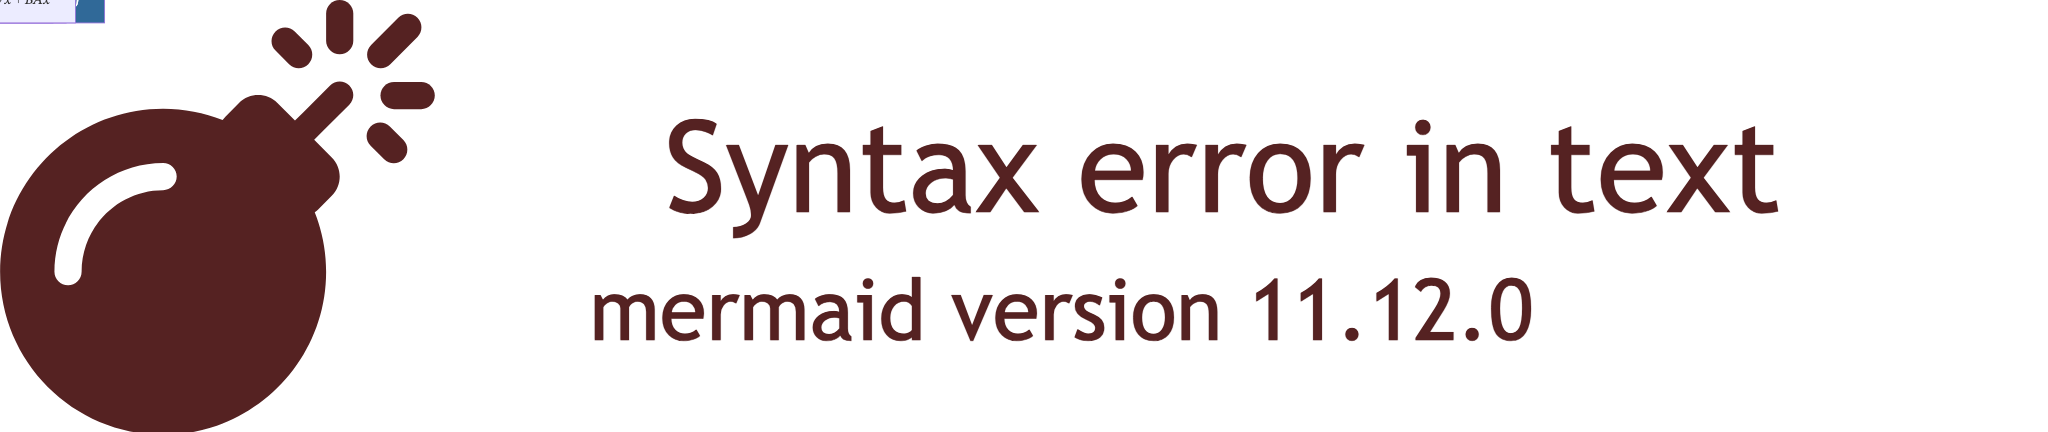

La idea es que los **cambios necesarios** para adaptar el modelo son de
“bajo rango”: no necesitas modificar los millones de pesos de W, solo
unas pocas direcciones principales. Las matrices A y B capturan esas
direcciones con una fracción de los parámetros.

#### Intuición del rango bajo

Imagina una imagen de 1000×1000 píxeles (1 millón de valores). Si la
describes con 10 factores principales (rango 10), solo necesitas
1000×10 + 10×1000 = 20.000 valores. Has comprimido **50×** sin perder la
esencia.

Lo mismo aplica a las matrices de pesos del Transformer: los cambios
necesarios para adaptar el modelo a un nuevo dominio ocupan pocas
direcciones principales.

| Parámetro | Qué controla | Valor típico | Impacto |
|------------------|------------------|------------------|------------------|
| **r** (rank) | Tamaño de las matrices A y B | 8-64 | Más alto = más capacidad, más VRAM |
| **alpha** | Factor de escala (alpha/r) | 16-128 | Controla cuánto influye LoRA vs el modelo base |
| **target_modules** | Qué capas del Transformer se adaptan | `q_proj, v_proj` | Más módulos = más parámetros |
| **dropout** | Regularización | 0.05-0.1 | Evita overfitting en datasets pequeños |

In [3]:
from peft import LoraConfig

config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

print(f"Configuración LoRA:")
print(f"  Rank (r): {config.r}")
print(f"  Alpha: {config.lora_alpha}")
print(f"  Escala efectiva: alpha/r = {config.lora_alpha / config.r}")
print(f"  Módulos objetivo: {config.target_modules}")
print(f"  Dropout: {config.lora_dropout}")

Configuración LoRA:
  Rank (r): 16
  Alpha: 32
  Escala efectiva: alpha/r = 2.0
  Módulos objetivo: {'v_proj', 'q_proj'}
  Dropout: 0.05

> **Configuración recomendada para empezar**
>
> - **r=8, alpha=16, target_modules=\[‘q_proj’, ‘v_proj’\]** — mínima,
>   funciona bien para la mayoría de casos
> - **r=16, alpha=32, target_modules=\[‘q_proj’, ‘k_proj’, ‘v_proj’,
>   ‘o_proj’\]** — más capacidad, más VRAM
> - **r=64, alpha=128** — solo si tienes muchos datos (\>10k ejemplos) y
>   VRAM suficiente

------------------------------------------------------------------------

### QLoRA: fine-tuning en GPU de consumidor

**QLoRA** combina LoRA con **cuantización a 4 bits**: el modelo base se
comprime para que ocupe menos memoria, y solo los adaptadores LoRA se
entrenan en precisión completa.

**QLoRA es como hacer la mudanza en una furgoneta en vez de un camión:
el modelo base viaja comprimido (4 bits) y solo las notas adhesivas
(LoRA) ocupan espacio real.**

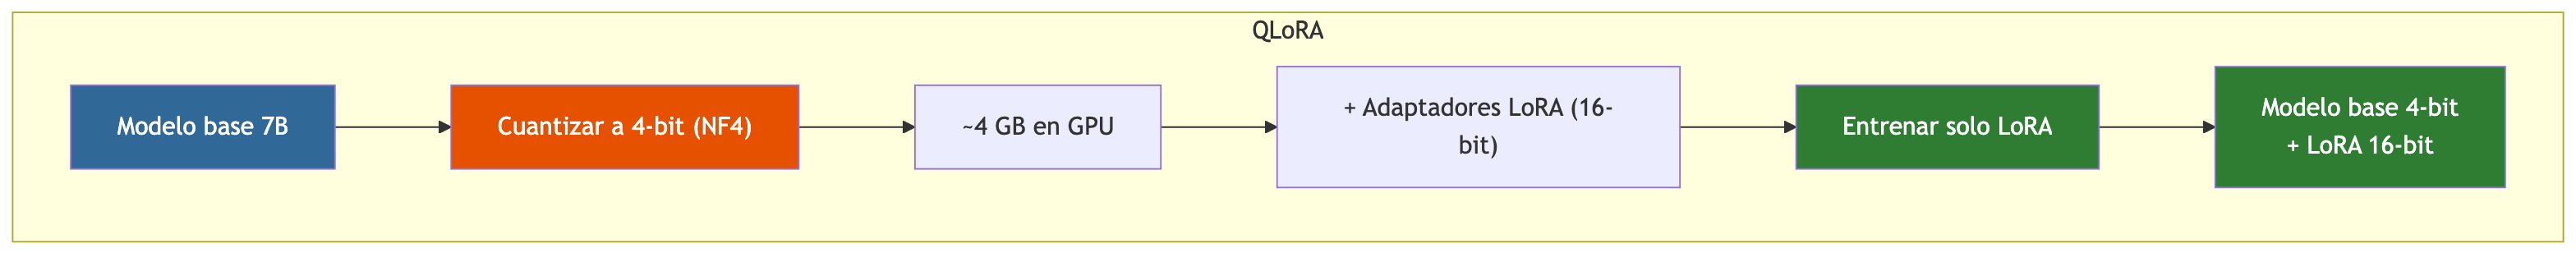

| Enfoque | Modelo 7B en GPU | VRAM necesaria |
|------------------------|------------------------|------------------------|
| Fine-tuning completo (16-bit) | 14 GB pesos + 42 GB optimizador | ~56 GB |
| LoRA (16-bit) | 14 GB pesos (congelados) + 0.1 GB LoRA | ~16 GB |
| **QLoRA (4-bit)** | **4 GB pesos (congelados) + 0.1 GB LoRA** | **~6 GB** |

Con QLoRA puedes hacer fine-tuning de un modelo 7B en una **GPU de Colab
gratuita** (T4, 16 GB VRAM).

In [4]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype="float16",
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B",
    quantization_config=bnb_config,
    device_map="auto",
)

print(f"Modelo cargado en 4-bit")
print(f"  Parámetros totales: {model.num_parameters():,}")
print(f"  VRAM usada: ~{sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6:.0f} MB (solo pesos)")

> **QLoRA vs LoRA: ¿pierdes calidad?**
>
> QLoRA reduce la calidad ligeramente vs LoRA 16-bit. Para la mayoría de
> casos la diferencia es despreciable (\<2% en benchmarks), pero si
> necesitas máxima precisión y tienes VRAM suficiente, usa LoRA sin
> cuantizar.

------------------------------------------------------------------------

### Otras técnicas PEFT

LoRA y QLoRA cubren el 95% de los casos prácticos. Las demás técnicas
son relevantes si lees papers o trabajas en investigación:

| Técnica | Idea | Parámetros añadidos | Cuándo usarla |
|------------------|------------------|------------------|------------------|
| **LoRA** | Matrices de bajo rango en capas lineales | ~0.1-1% | La más versátil, recomendada por defecto |
| **QLoRA** | LoRA + cuantización 4-bit | ~0.1-1% | Cuando la VRAM es limitada |
| **Adapters** | Capas bottleneck entre capas del Transformer | ~1-3% | Investigación, menos soporte en herramientas |
| **Prefix-tuning** | Prefijos aprendidos en cada capa | ~0.1% | Generación de texto, menos popular |
| **Prompt-tuning** | Soft prompts aprendidos | ~0.01% | Modelos muy grandes (\>10B), pocos datos |

> **En la práctica**
>
> Si estás empezando, usa **LoRA** (o **QLoRA** si tienes poca VRAM).
> Las demás técnicas tienen casos de uso muy específicos y menos soporte
> en las herramientas habituales (Hugging Face, TRL, etc.).

------------------------------------------------------------------------

### Infraestructura y ejemplo en Colab

El stack tecnológico para fine-tuning eficiente es:

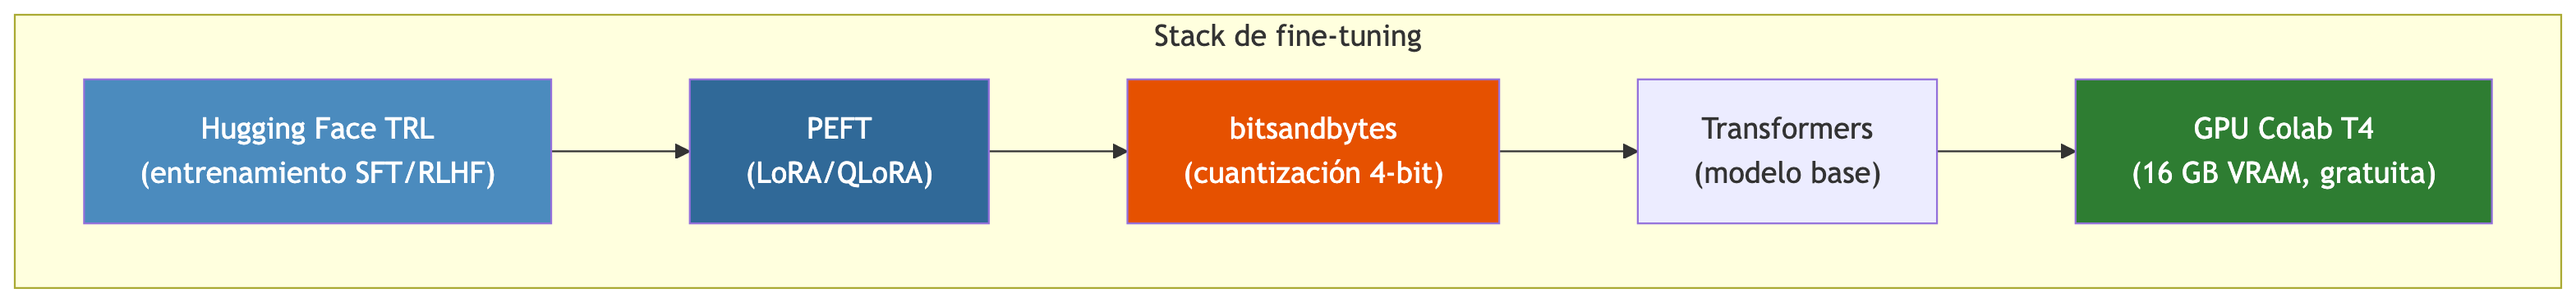

El siguiente ejemplo muestra un fine-tuning mínimo con TRL (Supervised
Fine-Tuning) sobre un modelo pequeño. Está diseñado para ejecutarse en
**Colab con GPU T4 gratuita**.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from trl import SFTConfig, SFTTrainer
from datasets import Dataset

model_name = "Qwen/Qwen3-0.6B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype="float16",
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

train_data = {
    "text": [
        "### Instrucción:\nClasifica el sentimiento de esta reseña.\n\n### Entrada:\nEl producto llegó roto y la atención fue pésima.\n\n### Respuesta:\nSentimiento: NEGATIVO. El cliente expresa insatisfacción con el estado del producto y el servicio recibido.",
        "### Instrucción:\nClasifica el sentimiento de esta reseña.\n\n### Entrada:\nTodo perfecto, entrega rápida y bien embalado.\n\n### Respuesta:\nSentimiento: POSITIVO. El cliente destaca la calidad del envío y el embalaje.",
        "### Instrucción:\nClasifica el sentimiento de esta reseña.\n\n### Entrada:\nEl paquete llegó ayer por la tarde.\n\n### Respuesta:\nSentimiento: NEUTRAL. El cliente solo informa de la recepción sin expresar valoración.",
    ]
}
dataset = Dataset.from_dict(train_data)

training_args = SFTConfig(
    output_dir="./lora-output",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=1,
    save_strategy="no",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    processing_class=tokenizer,
)

trainer.train()

prompt = "### Instrucción:\nClasifica el sentimiento de esta reseña.\n\n### Entrada:\nEl diseño es bonito pero la batería no dura nada.\n\n### Respuesta:\n"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=50)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

> **Sobre este ejemplo**
>
> - El modelo `Qwen3-0.6B` es pequeño (600M parámetros) para que el
>   ejemplo sea rápido. En tu proyecto puedes usar modelos mayores (7B)
>   con QLoRA.
> - El dataset tiene solo 3 ejemplos para ilustrar el formato. En la
>   práctica necesitas **cientos o miles** de ejemplos para un
>   fine-tuning efectivo.
> - El formato `### Instrucción / ### Entrada / ### Respuesta` es el
>   estándar para SFT (Supervised Fine-Tuning).

> **La calidad del dataset es lo más importante**
>
> El fine-tuning con datos de baja calidad produce un modelo **peor**
> que el base. Antes de hacer fine-tuning:
>
> 1.  **Revisa** cada ejemplo manualmente
> 2.  **Asegura** consistencia en el formato
> 3.  **Incluye** casos edge (respuestas negativas, neutrales, ambiguas)
> 4.  **Empieza** con 100-500 ejemplos de alta calidad antes de escalar

------------------------------------------------------------------------

### Resumen

| Técnica | VRAM (modelo 7B) | Calidad | Caso de uso |
|------------------|------------------|------------------|------------------|
| Fine-tuning completo | ~56 GB | Máxima | Investigación, recursos ilimitados |
| LoRA | ~16 GB | Alta | Uso general, GPU A100/4090 |
| QLoRA | ~6 GB | Alta (ligeramente menor) | GPU de consumidor, Colab gratuito |
| Prompting / RAG | 0 GB extra | Depende del modelo base | La mayoría de casos prácticos |

> **Árbol de decisión final**
>
> 1.  ¿Tu problema se resuelve con **prompting**? → No hagas
>     fine-tuning.
> 2.  ¿Necesitas **conocimiento actualizable**? → Usa **RAG**.
> 3.  ¿Necesitas **comportamiento/formato específico** y tienes datos de
>     calidad? → **LoRA** (o **QLoRA** si tienes poca VRAM).
> 4.  ¿Necesitas **ambos** (conocimiento + comportamiento)? → **RAG +
>     LoRA**.

------------------------------------------------------------------------

## Referencias

- Hu, E. et al. (2022). **LoRA: Low-Rank Adaptation of Large Language
  Models**. ICLR. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
- Dettmers, T. et al. (2023). **QLoRA: Efficient Finetuning of Quantized
  Language Models**. NeurIPS.
  [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)
- He, J. et al. (2022). **Towards a Unified View of Parameter-Efficient
  Transfer Learning**. ICLR.
  [arXiv:2110.04366](https://arxiv.org/abs/2110.04366)
- Lester, B. et al. (2021). **The Power of Scale for Parameter-Efficient
  Prompt Tuning**. EMNLP.
  [arXiv:2104.08691](https://arxiv.org/abs/2104.08691)

------------------------------------------------------------------------

> Has completado la teoría del **Bloque 3**. Ahora pasa al taller
> práctico: **[HPD 4 — Sistema RAG sobre datos
> mixtos](../evaluables/hpd4-rag-mixto.qmd)**.